In [1]:

# IMPORTS

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:

# DATA PREPROCESSING

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Data Loaded Successfully")

100%|███████████████████████████████████████████████████████████████| 26.4M/26.4M [00:02<00:00, 9.10MB/s]
100%|███████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 1.22MB/s]
100%|███████████████████████████████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 8.09MB/s]
100%|███████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 24.8MB/s]


Data Loaded Successfully


In [3]:

# NOISE ADDITION FUNCTION

def add_noise(images, noise_factor=0.3):
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

In [4]:
# BASELINE MODEL (Simple CNN)

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [5]:
# IMPROVED MODEL

class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),     
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),     
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),        
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [6]:

# TRAIN FUNCTION

def train_model(model, train_loader, epochs=5):
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

    end_time = time.time()
    training_time = end_time - start_time

    return training_time

In [7]:

# EVALUATION FUNCTION

def evaluate_model(model, test_loader, noisy=False):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            if noisy:
                images = add_noise(images)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [8]:
print("========== BASELINE MODEL ==========")

baseline_model = BaselineCNN()

baseline_time = train_model(baseline_model, train_loader)

baseline_clean_acc = evaluate_model(baseline_model, test_loader, noisy=False)
baseline_noisy_acc = evaluate_model(baseline_model, test_loader, noisy=True)

print(f"Baseline Clean Accuracy: {baseline_clean_acc:.2f}%")
print(f"Baseline Noisy Accuracy: {baseline_noisy_acc:.2f}%")
print(f"Training Time: {baseline_time:.2f} sec")

========== BASELINE MODEL ==========
Epoch [1/5], Loss: 432.8302
Epoch [2/5], Loss: 273.3026
Epoch [3/5], Loss: 231.1827
Epoch [4/5], Loss: 204.4717
Epoch [5/5], Loss: 182.3320
Baseline Clean Accuracy: 91.15%
Baseline Noisy Accuracy: 44.90%
Training Time: 66.49 sec


In [9]:
print("\n========== IMPROVED MODEL ==========")

improved_model = ImprovedCNN()

improved_time = train_model(improved_model, train_loader)

improved_clean_acc = evaluate_model(improved_model, test_loader, noisy=False)
improved_noisy_acc = evaluate_model(improved_model, test_loader, noisy=True)

print(f"Improved Clean Accuracy: {improved_clean_acc:.2f}%")
print(f"Improved Noisy Accuracy: {improved_noisy_acc:.2f}%")
print(f"Training Time: {improved_time:.2f} sec")


========== IMPROVED MODEL ==========
Epoch [1/5], Loss: 401.4671
Epoch [2/5], Loss: 282.4922
Epoch [3/5], Loss: 243.3467
Epoch [4/5], Loss: 218.8844
Epoch [5/5], Loss: 196.2492
Improved Clean Accuracy: 91.41%
Improved Noisy Accuracy: 35.74%
Training Time: 79.31 sec


In [10]:
# RESULTS COMPARISON

print("\n========== FINAL COMPARISON ==========")

print(f"{'Metric':<20}{'Baseline':<15}{'Improved'}")
print("-"*50)
print(f"{'Clean Accuracy':<20}{baseline_clean_acc:.2f}%{'':<10}{improved_clean_acc:.2f}%")
print(f"{'Noisy Accuracy':<20}{baseline_noisy_acc:.2f}%{'':<10}{improved_noisy_acc:.2f}%")
print(f"{'Training Time':<20}{baseline_time:.2f}s{'':<10}{improved_time:.2f}s")


========== FINAL COMPARISON ==========
Metric              Baseline       Improved
--------------------------------------------------
Clean Accuracy      91.15%          91.41%
Noisy Accuracy      44.90%          35.74%
Training Time       66.49s          79.31s


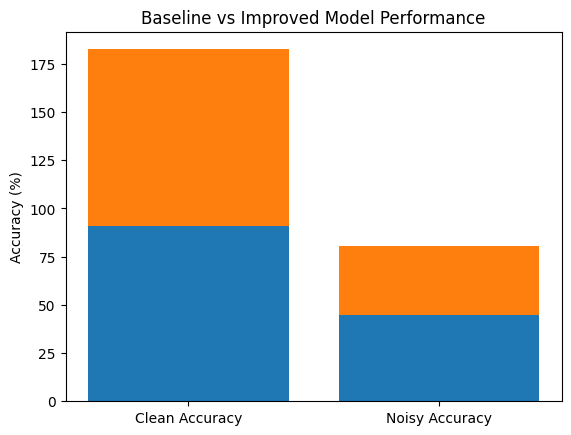

In [12]:
# VISUAL COMPARISON (OPTIONAL)

labels = ['Clean Accuracy', 'Noisy Accuracy']
baseline_scores = [baseline_clean_acc, baseline_noisy_acc]
improved_scores = [improved_clean_acc, improved_noisy_acc]

x = range(len(labels))

plt.bar(x, baseline_scores)
plt.bar(x, improved_scores, bottom=baseline_scores)

plt.xticks(x, labels)
plt.title("Baseline vs Improved Model Performance")
plt.ylabel("Accuracy (%)")

plt.show()